In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *

In [242]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Tecnologies

In [243]:
import re
import pandas as pd

def encontrar_linguagem_robusta(tags_texto, linguagens_alvo):
    """
    Verifica se alguma linguagem alvo está presente na string de tags,
    usando uma regex robusta para lidar com caracteres especiais (+, #).
    """
    if pd.isna(tags_texto) or not tags_texto.strip():
        return 'N/a'

    tags_texto_lower = tags_texto.lower()

    for lang in linguagens_alvo:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)
        
        regex_busca = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'
    
        if re.search(regex_busca, tags_texto_lower):
            return lang
            
    return 'N/a'

In [244]:
LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Obj-C', 'Go', 'Perl', 'Ruby', 'Delphi', 'Powershell', 'SQL', 'TSQL', 'Vbnet', 'Lisp']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

df['language'] = df['technologies'].str.lower().apply(
    lambda x: encontrar_linguagem_robusta(x, LANGUAGES)
)

In [245]:
df['language'].value_counts() / df.shape[0] * 100

language
N/a           55.518395
Java          14.046823
C#            11.036789
JavaScript     4.682274
PHP            4.682274
Python         3.678930
C++            2.341137
C              1.003344
Go             0.668896
Perl           0.334448
Vbnet          0.334448
Obj-C          0.334448
Delphi         0.334448
Lisp           0.334448
Ruby           0.334448
SQL            0.334448
Name: count, dtype: float64

<Axes: ylabel='language'>

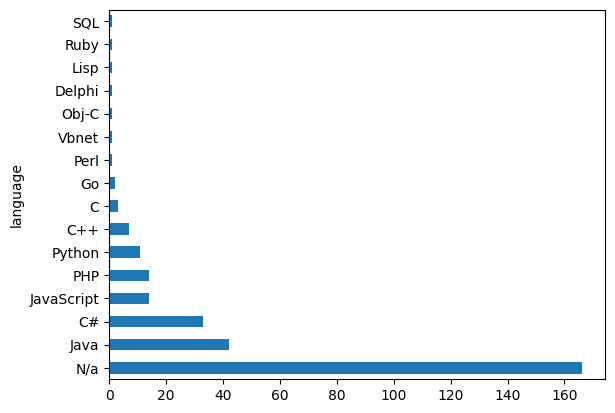

In [246]:
df['language'].value_counts().plot.barh()

In [247]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove as linguagens especificadas da string de tecnologias.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'Others'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    # Join back
    return ', '.join(filtered_list) if filtered_list else 'Others'

# Remove languages from technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [248]:
def normalize_technology_terms(tech_string):
    if pd.isna(tech_string) or not tech_string.strip():
        return 'Others'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    normalized_list = []
    
    for tech in tech_list:
        if not tech or tech.lower() == 'Others':
            continue
        
        tech_lower = tech.lower()
        normalized = tech_lower
        
        # Normalizar variações de algoritmos criptográficos
        
        # AES (aes-128, aes-256, aes128, aes256, etc.)
        if any(x in normalized for x in ['aes']):
            normalized = 'aes'
        
        # DES (des-ede, des3, des-3, triple-des, etc.)
        elif any(x in normalized for x in ['des']) and any(x in normalized for x in ['ede', '3']):
            normalized = 'des'
        elif normalized == 'des':
            normalized = 'des'
        
        # RC4 / ARCFOUR (rc4, rc-4, arcfour, etc.)
        elif any(x in normalized for x in ['rc4', 'rc-4', 'arcfour']):
            normalized = 'rc4'
        
        # RSA (rsa, rsa-2048, rsa-4096, rsa2048, etc.)
        elif any(x in normalized for x in ['rsa']):
            normalized = 'rsa'
        
        # SHA (sha, sha1, sha-1, sha256, sha-256, sha512, sha-512, etc.)
        elif any(x in normalized for x in ['sha']):
            if 'sha' in normalized and '256' in normalized:
                normalized = 'sha-256'
            elif 'sha' in normalized and '512' in normalized:
                normalized = 'sha-512'
            elif 'sha' in normalized and '1' in normalized:
                normalized = 'sha-1'
            else:
                normalized = 'sha'
        
        # MD5
        elif 'md5' in normalized or 'md-5' in normalized:
            normalized = 'md5'
        
        # PBKDF2 (pbkdf2, pbkdf-2, pkdf2 com typos, etc.)
        elif any(x in normalized for x in ['pbkdf', 'pkdf']):
            normalized = 'pbkdf2'
        
        # ECC / ECDSA / ECDH (todos viram ECC - curvas elípticas)
        elif any(x in normalized for x in ['ecc', 'ecdsa', 'ecdh', 'elliptic']):
            normalized = 'ecc'
        
        # HMAC (hmac, hmac-sha, hmac-sha256, etc.)
        elif 'hmac' in normalized:
            normalized = 'hmac'
        
        # TLS / SSL (ssl, tls, tls1.2, tls-1.2, sslv3, etc.)
        elif any(x in normalized for x in ['tls', 'ssl']):
            if any(x in normalized for x in ['1.2', '1_2', 'tlsv1.2', 'tls12']):
                normalized = 'tls-1.2'
            elif any(x in normalized for x in ['1.3', '1_3', 'tlsv1.3', 'tls13']):
                normalized = 'tls-1.3'
            else:
                normalized = 'tls'
        
        # OAuth (oauth, oauth2, oauth-2, etc.)
        elif 'oauth' in normalized:
            normalized = 'oauth'
        
        # JWT (jwt, json-web-token, jsonwebtoken, etc.)
        elif any(x in normalized for x in ['jwt', 'json-web', 'jsonweb']):
            normalized = 'jwt'
        
        # BASE64 (base64, base-64, base_64, etc.)
        elif any(x in normalized for x in ['base64', 'base-64', 'base_64']):
            normalized = 'base64'
        
        # HTTP / HTTPS
        elif 'https' in normalized:
            normalized = 'https'
        elif 'http' in normalized:
            normalized = 'http'
        
        # Remover espaços extras
        normalized = ' '.join(normalized.split())
        
        # Evitar duplicatas
        if normalized not in normalized_list:
            normalized_list.append(normalized)
    
    return ', '.join(normalized_list) if normalized_list else 'Others'


# Aplicar normalização
df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)


In [249]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)

In [250]:
contagem_palavras_clean = exploded.value_counts()
contagem_palavras_clean.head(10)

technologies_clean
aes       91
rsa       44
others    31
tls       29
sha       17
md5       13
.net      12
hmac      12
hash      12
pbkdf2    10
Name: count, dtype: int64

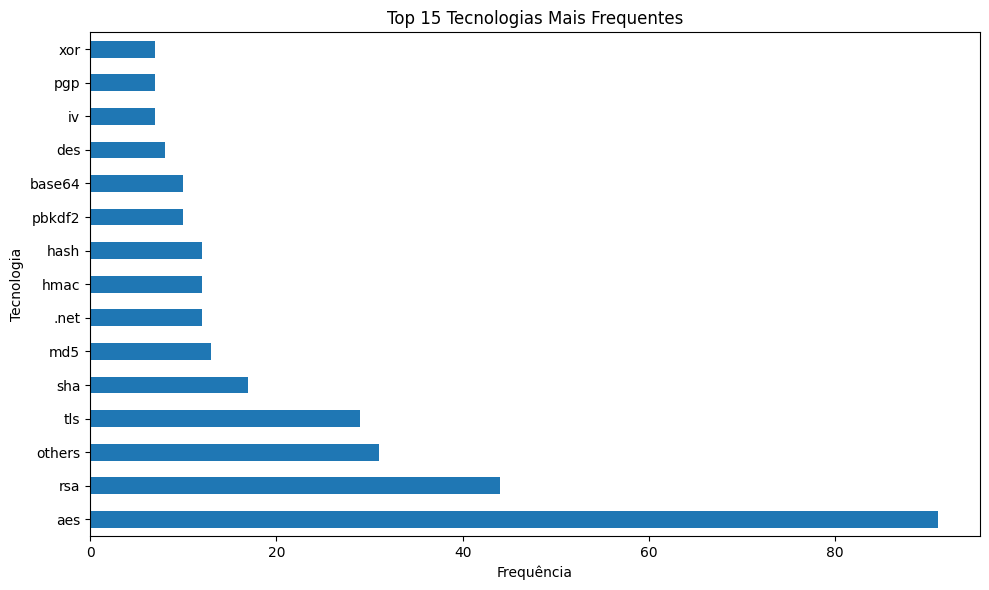

In [251]:
contagem_palavras_clean.head(15).plot.barh(figsize=(10, 6))
plt.title('Top 15 Tecnologias Mais Frequentes')
plt.xlabel('Frequência')
plt.ylabel('Tecnologia')
plt.tight_layout()
plt.show()

In [252]:
pd.set_option('display.max_rows', None)

In [253]:
contagem_palavras_clean / df.shape[0] * 100

technologies_clean
aes                         30.434783
rsa                         14.715719
others                      10.367893
tls                          9.698997
sha                          5.685619
md5                          4.347826
.net                         4.013378
hmac                         4.013378
hash                         4.013378
pbkdf2                       3.344482
base64                       3.344482
des                          2.675585
iv                           2.341137
pgp                          2.341137
xor                          2.341137
encryption                   2.006689
cryptojs                     2.006689
truecrypt                    2.006689
bouncycastle                 1.672241
sql server                   1.672241
sha-256                      1.672241
mysql                        1.672241
gcm                          1.337793
cbc                          1.337793
sha-1                        1.337793
bcrypt                       1.

## Tecnologies along time

In [254]:
df = pd.read_csv(CLASSIFIED_POSTS)
df = df[df['type'] == 'question']

Total de tópicos: 15


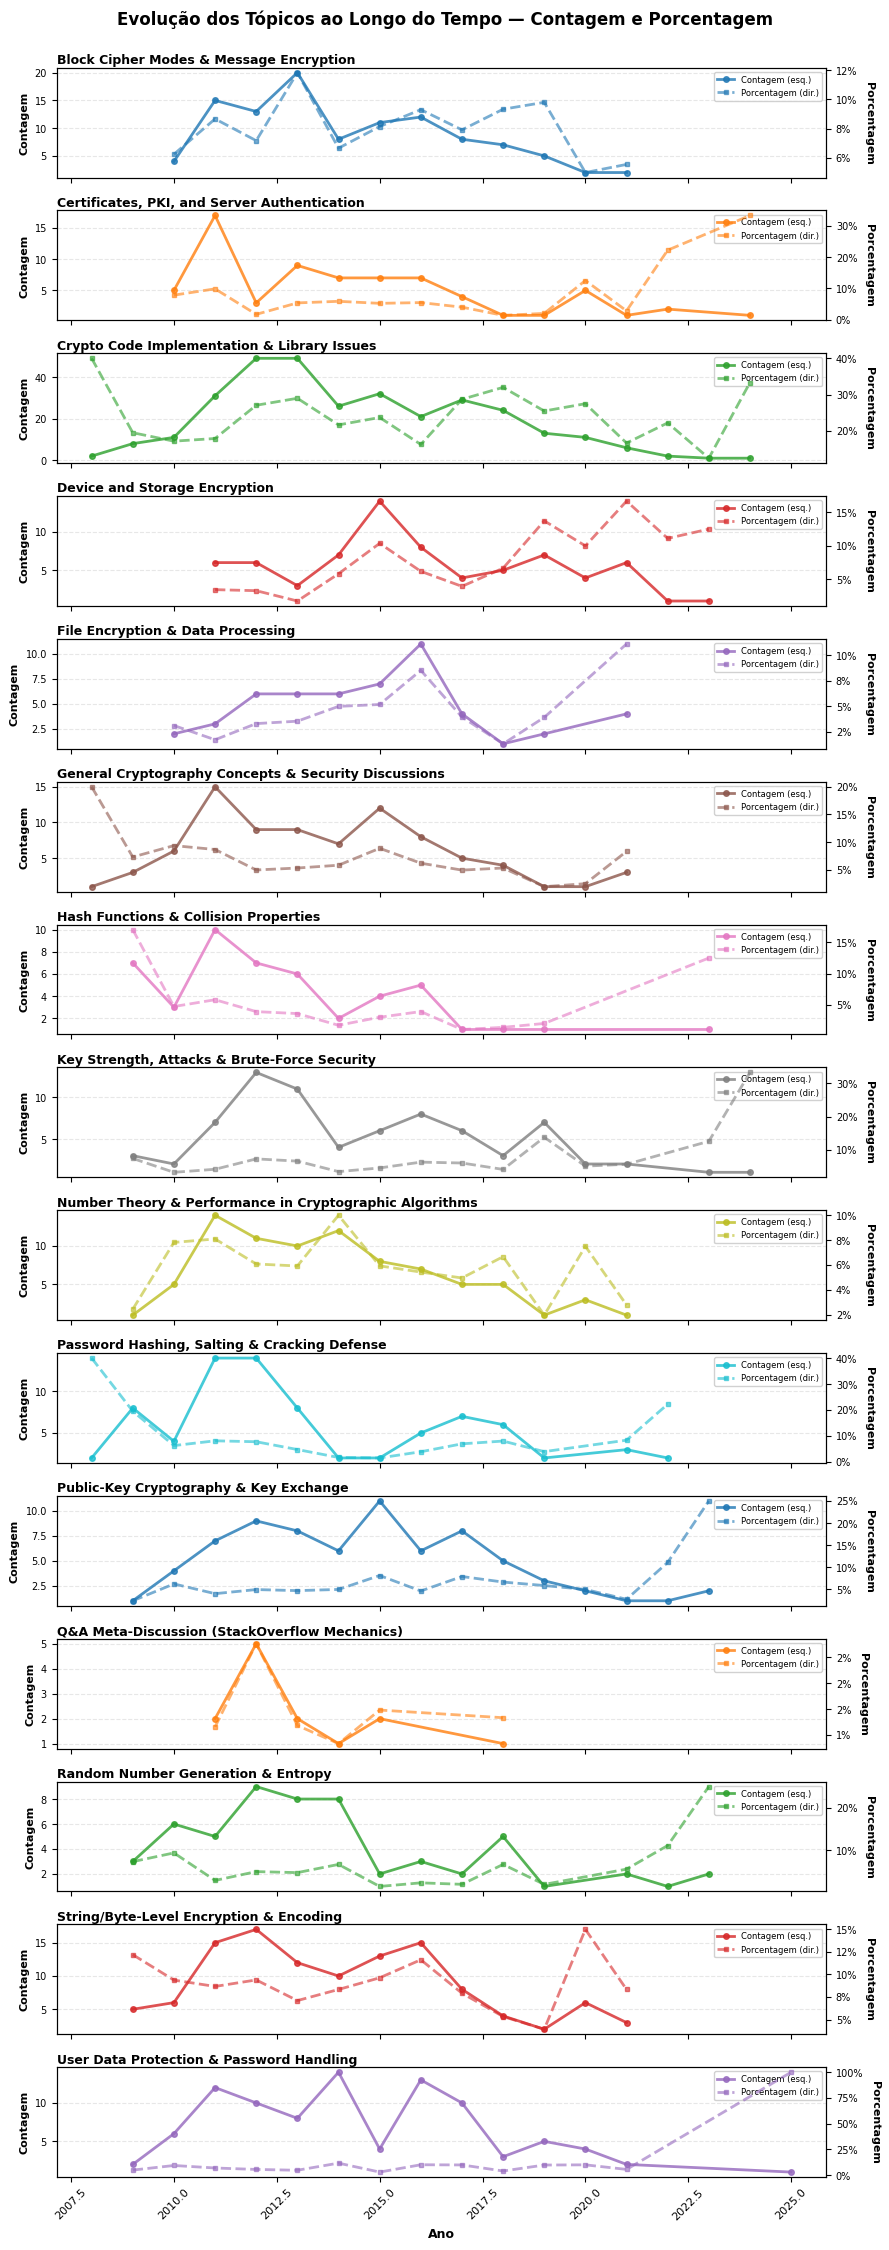

In [255]:
import pandas as pd
import matplotlib.pyplot as plt

# Converter creation_date para datetime se necessário
df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

# Extrair o ano
df['year'] = df['creation_date'].dt.year

# Agrupar por ano e tópico, contar ocorrências
topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')

# Calcular total de posts por ano
total_by_year = df.groupby('year').size().reset_index(name='total')

# Merge para calcular porcentagem
topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

# Obter todos os tópicos únicos
all_topics = sorted(df['topic'].unique())
n_topics = len(all_topics)

print(f"Total de tópicos: {n_topics}")

# Criar figura com subplots menores
fig, axes = plt.subplots(n_topics, 1, figsize=(9, 1.5 * n_topics), sharex=True)

# Garantir que axes seja sempre uma lista
if n_topics == 1:
    axes = [axes]

# Definir cores para cada tópico
colors = plt.cm.tab10(range(10))

# Criar um gráfico para cada tópico
for idx, topic in enumerate(all_topics):
    ax = axes[idx]
    
    # Criar eixo secundário para porcentagem
    ax2 = ax.twinx()
    
    # Filtrar dados do tópico
    topic_data = topic_by_year[topic_by_year['topic'] == topic].sort_values('year')
    
    if not topic_data.empty:
        color = colors[idx % 10]
        
        # Plotar contagem (linha sólida)
        line1 = ax.plot(topic_data['year'], topic_data['count'], 
                        marker='o', linewidth=2, markersize=4, 
                        color=color, label='Contagem (eixo esq.)',
                        linestyle='-', alpha=0.8)
        
        # Plotar porcentagem (linha tracejada)
        line2 = ax2.plot(topic_data['year'], topic_data['percentage'], 
                         marker='s', linewidth=2, markersize=3,
                         color=color, label='Porcentagem (eixo dir.)',
                         linestyle='--', alpha=0.6)
    
    # Configurar eixo esquerdo (contagem)
    ax.set_ylabel('Contagem', fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Configurar eixo direito (porcentagem)
    ax2.set_ylabel('Porcentagem', fontsize=8, fontweight='bold', rotation=270, labelpad=12)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    
    # Título do tópico
    ax.set_title(f'{topic}', fontsize=9, fontweight='bold', loc='left', pad=3)
    
    # Remover label do eixo x de todos exceto o último
    if idx < n_topics - 1:
        ax.tick_params(labelbottom=False)
    
    # Adicionar legenda pequena
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, ['Contagem (esq.)', 'Porcentagem (dir.)'], 
              loc='upper right', fontsize=6, framealpha=0.9)

# Configurar o eixo x apenas no último subplot
axes[-1].set_xlabel('Ano', fontsize=9, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=8, rotation=45)

# Ajustar layout
plt.suptitle('Evolução dos Tópicos ao Longo do Tempo — Contagem e Porcentagem', 
             fontsize=12, fontweight='bold', y=0.998)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()